# Image Pair Ranking

Задача: по данным из parquet-файлов предсказать, какая из двух сгенерированных картинок прошла экспертную комиссию и была признана лучшей.

Финальная метрика: `roc_auc_score`.

Kaggle name: Yulia Nikitina\
Real name: Юлия Никитина

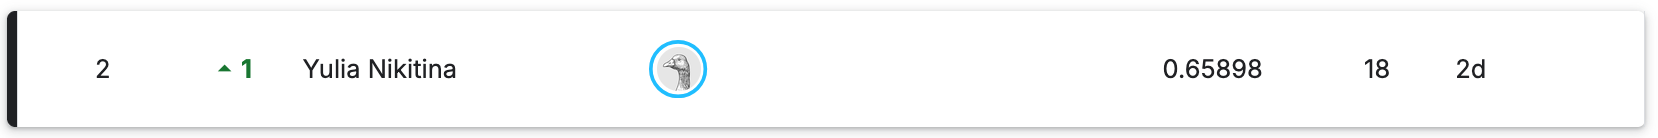

<div style="
    border: 1px solid #f59e0b;
    background: #fffbeb;
    color: #92400e;
    padding: 12px 14px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    min-height: 100px;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    <strong>⚠️ В процессе сборки</strong><br>
    Ноутбук постепенно переносится из рабочих ноутбуков в единый отчет. 
    <br>Некоторые разделы пока содержат только структуру и будут дополнены позже.
</div>

## Дневник экспериментов

**Этап 1. Baseline на ручных признаках**

Работа началась с предположения, что экспертная комиссия могла выбирать победителя по базовому качеству изображения. Для каждой картинки были вычислены простые image-quality признаки: яркость, контраст, резкость, цветовые статистики, а также их различия внутри пары. На этих признаках был обучен CatBoost. Результат оказался слабым, простые характеристики практически не позволяли отличать победителя пары. Стало понятно, что задача требует более содержательного представления изображения.

`ROC AUC: 0.60177`

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 2. Baseline на pre-trained embeddings CLIP ViT-B/32 + CatBoost**

После отказа от ручных признаков внимание было перенесено на готовые визуальные эмбеддинги. В качестве первого энкодера использовался OpenAI CLIP ViT-B/32.

Для каждой пары строились признаки:

* embedding image_1;
* embedding image_2;
* разность эмбеддингов;
* абсолютная разность;
* покомпонентное произведение.

На этих признаках обучался CatBoost. Этот этап стал первым действительно сильным baseline и показал, насколько информативнее оказываются предобученные визуальные представления по сравнению с handcrafted-признаками.

`ROC AUC = 0.64523`

Попытка ввести **swapped augmentation** дала отрицательный результат. В этом датасете есть сильный positional bias: target mean ≈ 0.347 (image_2 выигрывает примерно в 65% пар), порядок изображений явно несет информацию. Для этой задачи модель должна учить не абстрактное симметричное предпочтение между двумя изображениями, а конкретное распределение P(image_1 лучше | image_1, image_2, исходная позиция), поэтому исходный порядок нужно сохранять. Для финального пайплайна правильно использовать пары в исходном порядке, без swapped augmentation.

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 3. Проверка эстетического качества**

Предположение: победитель определяется общей эстетикой изображения. Протестирован LAION aesthetic head на эмбеддингах CLIP ViT-B/32. Результат оказался слабым, aesthetic score почти не отличался от случайного угадывания.  Стало очевидно, что задача не сводится к сравнению "более красивой" и "менее красивой" картинки. Во многих случаях выигрывали изображения, которые выглядели менее эстетично, но вероятно лучше соответствовали промпту для генерации.

`ROC AUC: 0.51726`

Почему LAION aesthetic хуже

LAION aesthetic predictor – почти один скалярный скор красоты/эстетики. Он сжимает картинку в одно число, но тут задача сложнее – выбрать лучшую из двух сгенерированных картинок по экспертной комиссии. Там может быть не только “красиво”, но и отсутствие артефактов, правильность деталей, композиция, соответствие скрытому промпту, если он был при генерации. Один aesthetic score слишком грубый для этой задачи. 


<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 4. Проверка эффективности vision-only self-supervised энкодера (DINOv2)**

Следующее предположение: может быть, vision-only self-supervised encoder лучше видит визуальную структуру, локальные детали, артефакты, форму объектов, композицию, текстуры — то, что CLIP могут частично сглаживать из-за текстового предобучения. Был выбран DINOv2 как один из самых сильных энкодеров такого типа.\
DINOv2 был проверен в быстрой one-split CatBoost-валидации. ROC AUC оказался существенно ниже чему у CLIP-эмбеддинга, поэтому полный OOF pipeline для этой модели строить не стала.

`ROC AUC: 0.58377`

Почему DINO хуже CLIP

DINOv2 хорошо понимает объекты, формы, сцены, локальные паттерны. Но он не обучался напрямую связывать изображение с человеческими предпочтениями, стилем, эстетикой, “качество лучше/хуже”. CLIP обучался на связке картинка-текст, поэтому его эмбеддинги часто лучше несут признаки, похожие на человеческую оценку: “beautiful”, “sharp”, “professional”, “well composed”, “ugly”, “blurry” и т.п. Даже без промптов CLIP-эмбеддинг уже более семантически и эстетически ориентирован, и видимо для этой задачи такой подход лучше соответствует цели.


<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 5. Добавление Siamese comparator**

Следующей идеей стало использование тех же CLIP-эмбеддингов в парной нейронной модели. Обучена PyTorch Siamese-сеть с общей encoder-веткой и MLP-компаратором, обучаемая сравнивать два изображения. Несмотря на использование тех же самых эмбеддингов, сеть начала совершать ошибки в других местах, чем CatBoost. Их объединение дало первый заметный выигрыш ансамбля. На этом этапе стало ясно, что разнообразие downstream-моделей само по себе приносит пользу даже при одинаковом энкодере.

Негативное влияние swap augmentation подтвердилось и для siamese-модели:\
augment_swap=True:  `0.64673`\
augment_swap=False: `0.65506`

ROC AUC-метрики этого блока:\
CLIP ViT-B/32 CatBoost: `0.64523`\
CLIP ViT-B/32 Siamese:  `0.65038`\
CLIP ViT-B/32 blend:    `0.65877`


<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 6. Анализ похожих изображений**

Я также исследовала явные признаки похожести изображений: cosine similarity, distance features и near-duplicate indicators. Они давали небольшой диагностический сигнал и помогли лучше понять структуру датасета. Однако в финальном ансамбле эти признаки не использовались как отдельная ветка, вероятно, аналогичная информация уже была закодирована в pairwise embedding features (diff, abs_diff, mul). Более сложные similarity схемы и специальные модели для похожих пар локально выглядели перспективно, но на public leaderboard ухудшали результат.

CLIP quality / direction / single-image logreg: `0.61983`


<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 7. Переход на CLIP ViT-L/14**

Следующим шагом стала замена энкодера на более крупную модель CLIP ViT-L/14, которая имеет значительно больше параметров (Large вместо Base) и разбивает изображение на более мелкие патчи 14×14 вместо 32×32, поэтому получает больше визуальных токенов и лучше сохраняет локальные детали.
Этот эксперимент дал один из самых заметных приростов и показал, что выбор энкодера существенно влияет на качество модели.

CLIP ViT-L/14 CatBoost: `0.64971`\
CLIP ViT-L/14 Siamese: `0.64715`\
CLIP ViT-L/14 CatBoost + Siamese blend: `0.65913`

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 8. Объединение Base и Large**

После появления двух сильных CLIP-моделей они были объединены в общий ансамбль. Несмотря на принадлежность к одному семейству моделей, Base и Large оказались достаточно независимыми и хорошо дополняли друг друга. Их совместный blend оказался сильнее обеих моделей по отдельности.

CLIP Base + Large blend/meta: `0.66072`

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 9. Добавление SigLIP**

Следующим новым направлением стал переход к другому типу предобучения — SigLIP. SigLIP использует иную функцию обучения, поэтому его эмбеддинги содержат несколько другую информацию по сравнению с CLIP. Добавление SigLIP-256 стало еще одним крупным скачком качества. 

SigLIP-256 CatBoost: `0.65953`\
SigLIP-256 Siamese: `0.65078`

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 10. Построение расширенного ансамбля**

После накопления нескольких сильных моделей был сформирован expanded atomic blend, собранный из предсказаний базовых моделей. В него вошли:

* CLIP Base CatBoost;
* CLIP Base Siamese;
* CLIP Large CatBoost;
* CLIP Large Siamese;
* SigLIP-256 CatBoost;
* SigLIP-256 Siamese.

Этот ансамбль стал основой всех последующих экспериментов. После этого прирост от новых экспериментов стал значительно меньше.

Expanded atomic blend ROC AUC: `0.67290`

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 11. Поиск новых независимых энкодеров**

Чтобы найти новый независимый источник информации, протестированы:

* SigLIP-384;
* ConvNeXt;
* EVA-B;
* EVA-L;
* дополнительные image-quality признаки.

Самым удачным новым энкодером оказался EVA-B. Даже CatBoost на его эмбеддингах почти сравнялся с лучшим ансамблем на public leaderboard. После этого я попробовала обучить на тех же эмбеддингах Siamese-модель. По OOF она выглядела очень хорошо и после повторного подбора весов заметно улучшала локальную метрику. Но на public leaderboard этот прирост не повторился. В этот момент стало ясно, что высокий OOF уже не гарантирует улучшение на leaderboard.

После EVA-B стало заметно, что новые энкодеры продолжают приносить пользу, но уже совсем другого масштаба. Если раньше переход на CLIP Large или SigLIP давал заметный скачок качества, то SigLIP-384, ConvNeXt и EVA-L добавляли уже небольшие улучшения. По отдельности они выглядели не так впечатляюще, зато вместе усиливали финальный ансамбль и поэтому сохранили в нем свои веса.

SigLIP-384 CatBoost: `0.65883`\
OpenCLIP ConvNeXt CatBoost: `0.65073`\
EVA-B CatBoost: `0.65586`\
EVA-L CatBoost: `0.65079`

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 12. Проверка мета-моделей**

После накопления большого количества сильных атомарных моделей была проверена возможность заменить простой blend обучаемой мета-моделью.

Были протестированы несколько вариантов второго уровня:

- Ridge Regression;
- Logistic Regression;
- MLP;
- Pair MLP;
- similarity-bin blending;
- различные варианты meta-features.

Несмотря на локально привлекательные OOF-результаты, ни одна из мета-моделей не смогла стабильно превзойти простой линейный blend на leaderboard. Наиболее вероятной причиной оказалась высокая корреляция между атомарными моделями и относительно небольшой размер обучающей выборки, которого оказалось недостаточно для надежного обучения второго уровня. 
В результате было принято решение отказаться от сложного стекинга. Более устойчивым оказался простой линейный blend с усреднением top-N наборов весов, сгенерированных вокруг уже проверенного набора базовых коэффициентов.

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 13. Seed ensemble для CatBoost**

Поскольку пространство новых моделей практически исчерпалось, внимание было переключено на стабилизацию уже найденных сильных моделей. Для двух наиболее важных CatBoost-веток:

* SigLIP-256;
* EVA-B

были обучены несколько моделей с различными random seed, после чего их предсказания усреднялись. Такой seed ensemble оказался устойчивее одиночных моделей и улучшил private leaderboard.

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Этап 14. Консервативный reweight**

Заключительным экспериментом стал отказ от агрессивного поиска новых весов ансамбля. 

Вместо свободной оптимизации использовалось распределение Дирихле, центрированное вокруг уже проверенных весов. Затем усреднялись лучшие найденные варианты. Такой подход оказался более устойчивым, чем повторный поиск полностью новых комбинаций весов.

<hr style="border: none; border-top: 1px solid #e5e7eb;" />

**Итог**

За время соревнования стратегия постепенно изменилась. На ранних этапах основной прирост обеспечивали новые визуальные представления: переход от ручных признаков к CLIP, затем к CLIP Large, SigLIP и EVA-B.

На поздних этапах пространство новых моделей практически насытилось, и дальнейшие попытки добавлять новые архитектуры редко приносили устойчивый выигрыш. Лучший результат на private leaderboard был достигнут не за счет очередного нового энкодера или сложной мета-модели, а благодаря стабилизации уже найденных сильных компонентов: seed ensemble для ключевых CatBoost-моделей и консервативному повторному подбору весов ансамбля.

### Пространство моделей

<style>
  .model-table {
    border-collapse: collapse;
    width: 100%;
    table-layout: fixed;
    font-size: 14px;
  }
  .model-table th,
  .model-table td {
    border: 1px solid #d1d5db;
    padding: 8px;
    text-align: left;
    vertical-align: top;
    word-wrap: break-word;
  }
  .model-table .muted {
    color: #9ca3af;
  }
  .model-table .empty {
    background: #f9fafb;
    color: #9ca3af;
    text-align: center;
  }
  .yes {color: #16a34a; font-weight: 700;}
  .no {color: #dc2626; font-weight: 700;}
  .sep {border: none; border-top: 1px solid #e5e7eb;}
</style>

<p style="font-size: 13px; padding-bottom: 20px;">
  <span class="yes">✓</span> – пробовала, вошло в финальную модель;<br />
  <span class="no">×</span> – пробовала, не вошло в финальную модель;<br />
  <span style="color: #9ca3af;">серый текст</span> – есть модели / подходы, не применялись;<br />
  <span style="background: #f9fafb; color: #9ca3af;">светло-серый фон</span> – нет популярной готовой модели для этого сочетания.
</p>

<table class="model-table">
<colgroup>
  <col style="width: 16%;">
  <col style="width: 21%;">
  <col style="width: 21%;">
  <col style="width: 21%;">
  <col style="width: 21%;">
</colgroup>
<thead>
<tr>
<th>Backbone / pretraining objective</th>
<th>Supervised</th>
<th>Contrastive VLM</th>
<th>Sigmoid VLM</th>
<th>Self-supervised</th>
</tr>
</thead>

<tbody>

<tr>
<th>ViT</th>
<td class="muted">ViT (ImageNet)</td>
<td>
<span class="yes">✓</span> CLIP ViT-B/32
<br><span class="yes">✓</span> CLIP ViT-L/14
<hr class="sep">
<span class="no">×</span> LAION aesthetic head
<br>over CLIP ViT-B/32
</td>
<td>
<span class="yes">✓</span> SigLIP Large patch16-256
<br><span class="yes">✓</span> SigLIP Large patch16-384
</td>
<td>
<span class="no">×</span> DINOv2 ViT-S/14
</td>
</tr>

<tr>
<th>ConvNeXt</th>
<td><span class="no">×</span> ConvNeXt Base (ImageNet)</td>
<td><span class="yes">✓</span> OpenCLIP ConvNeXt Base W</td>
<td class="empty">—</td>
<td class="empty">—</td>
</tr>

<tr>
<th>ResNet</th>
<td class="muted">ResNet50, ...</td>
<td class="muted">
OpenAI CLIP RN50
<br>OpenCLIP RN50, ...
</td>
<td class="empty">—</td>
<td class="muted">MoCo v3 ResNet50, ...</td>
</tr>

<tr>
<th>EVA</th>
<td class="empty">—</td>
<td><span class="yes">✓</span> EVA-CLIP</td>
<td class="empty">—</td>
<td class="muted">EVA-02</td>
</tr>

<tr>
<th>Swin Transformer</th>
<td class="muted">Swin-T/B/L, ...</td>
<td class="muted">OpenCLIP Swin, ...</td>
<td class="empty">—</td>
<td class="muted">SimMIM Swin, ...</td>
</tr>

</tbody>
</table>

### Pipeline

### Финальный ансамбль и вклад отдельных моделей

| Модель | Вес | Standalone OOF ROC AUC |
|---|---:|---:|
| `siglip_256_catboost_ens3` | 0.17109 | 0.66385 |
| `eva_b_catboost_ens3` | 0.16568 | 0.66090 |
| `siglip_384_catboost` | 0.14911 | 0.65883 |
| `siglip_256_siamese` | 0.11308 | 0.65078 |
| `eva_l_catboost` | 0.08048 | 0.65079 |
| `clip_large_siamese` | 0.07842 | 0.64715 |
| `clip_base_siamese` | 0.07091 | 0.65038 |
| `openclip_convnext_catboost` | 0.06429 | 0.65073 |
| `clip_large_catboost` | 0.05751 | 0.64971 |
| `clip_base_catboost` | 0.04942 | 0.64523 |

Final ROC AUC: 0.6758478727

---

## Подготовка

In [117]:
%autosave 60

from pathlib import Path
import random
import warnings

import io
from PIL import Image, ImageStat, ImageFilter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, AutoModel
from transformers import CLIPModel, CLIPProcessor
from sklearn.model_selection import StratifiedKFold
import open_clip

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)


Autosaving every 60 seconds


In [81]:
SEED = 42
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
print(f'My device: {DEVICE}')


My device: mps


In [37]:
# Артефакты моделей сохраняются (эмбеддинги, predictions и веса)
ARTEFACTS_DIR = Path('artefacts')
ARTEFACTS_DIR.mkdir(exist_ok=True)

SUBMISSIONS_DIR = Path('submissions')
SUBMISSIONS_DIR.mkdir(exist_ok=True)


In [38]:
# загрузка данных
train = pd.read_parquet("data/train.parquet", engine="fastparquet")
test = pd.read_parquet("data/test.parquet", engine="fastparquet")
sample_submission = pd.read_csv("data/sample_submission.csv")


In [39]:
print(f'TRAIN shape: {train.shape}; {train.columns.tolist()}, ')
print(f'TEST shape:  {test.shape}; {test.columns.tolist()}')


TRAIN shape: (8710, 3); ['image_1', 'image_2', 'is_image1_better'], 
TEST shape:  (4290, 2); ['image_1', 'image_2']


In [57]:
def decode_image(image_bytes):
    return Image.open(io.BytesIO(image_bytes)).convert('RGB')


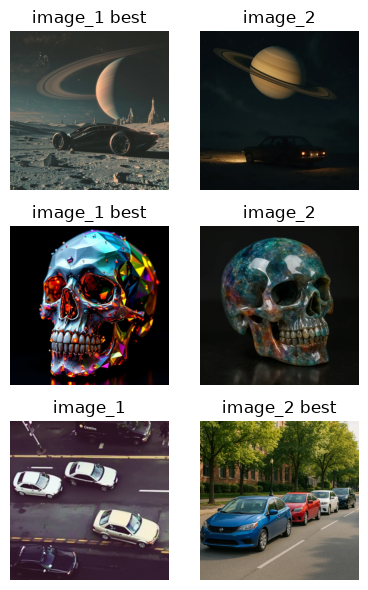

In [58]:
sample = train.sample(3)

fig, axes = plt.subplots(len(sample), 2, figsize=(4, 6))

for row_idx, (_, row) in enumerate(sample.iterrows()):
    best_col = 'image_1' if row['is_image1_better'] else 'image_2'

    for col_idx, col in enumerate(['image_1', 'image_2']):
        ax = axes[row_idx, col_idx]
        ax.imshow(decode_image(row[col]))
        ax.set_title(f'{col} best' if col == best_col else col)
        ax.axis('off')

plt.tight_layout()
plt.show()


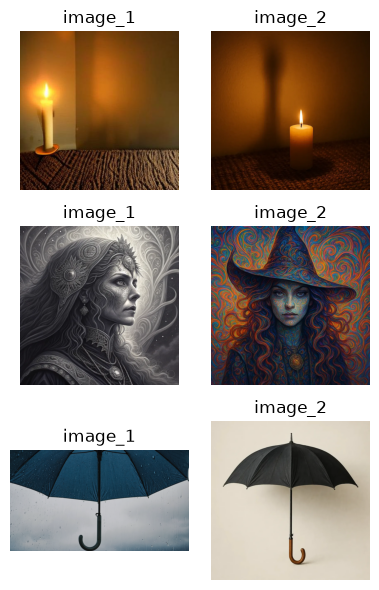

In [59]:
sample = test.sample(3)

fig, axes = plt.subplots(len(sample), 2, figsize=(4, 6))

for row_idx, (_, row) in enumerate(sample.iterrows()):
    for col_idx, col in enumerate(['image_1', 'image_2']):
        ax = axes[row_idx, col_idx]
        ax.imshow(decode_image(row[col]))
        ax.set_title(col)
        ax.axis('off')

plt.tight_layout()
plt.show()


---

## Baseline
Image statistics + CatBoost

In [42]:
# Извлекаем характеристики изображений

def image_features(image_bytes):
    image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    gray = image.convert('L')

    # rgb и grayscale версии изображения
    arr = np.array(image) / 255
    gray_arr = np.array(gray) / 255

    # гистограмма яркости
    hist = np.histogram(gray_arr, bins=32, range=(0, 1), density=True)[0]
    hist = hist / hist.sum()

    # градиенты яркости
    gy, gx = np.gradient(gray_arr)

    return {
        # размер изображения
        'width': image.width,
        'height': image.height,

        # общие характеристики
        'brightness': gray_arr.mean(),
        'contrast': gray_arr.std(),
        'saturation': arr.std(axis=2).mean(),
        'sharpness': np.array(gray.filter(ImageFilter.FIND_EDGES)).mean(),

        # статистики по каналам rgb
        'r_mean': arr[:, :, 0].mean(),
        'g_mean': arr[:, :, 1].mean(),
        'b_mean': arr[:, :, 2].mean(),
        'r_std': arr[:, :, 0].std(),
        'g_std': arr[:, :, 1].std(),
        'b_std': arr[:, :, 2].std(),

        # квантили яркости
        'brightness_p10': np.quantile(gray_arr, 0.10),
        'brightness_p50': np.quantile(gray_arr, 0.50),
        'brightness_p90': np.quantile(gray_arr, 0.90),

        # цветовое разнообразие
        'colorfulness': np.sqrt(
            arr[:, :, 0].std() ** 2
            + arr[:, :, 1].std() ** 2
            + arr[:, :, 2].std() ** 2
        ),
        
        # распределение и локальные изменения яркости
        'entropy': -(hist * np.log(hist + 1e-9)).sum(),
        'gradient_mean': np.sqrt(gx ** 2 + gy ** 2).mean(),
        'gradient_std': np.sqrt(gx ** 2 + gy ** 2).std(),
    }


In [ ]:
# признаки для одной пары изображений
def image_pair_features(row):
    image_1_features = image_features(row['image_1'])
    image_2_features = image_features(row['image_2'])

    features = {}
    for feature_name in image_1_features:
        features[f'{feature_name}_1'] = image_1_features[feature_name]
        features[f'{feature_name}_2'] = image_2_features[feature_name]

        # разница признаков между изображениями
        features[f'{feature_name}_diff'] = (
            image_1_features[feature_name] - image_2_features[feature_name]
        )

    return features

# считаем признаки для всех пар изображений
def pair_features(df):
    rows = Parallel(n_jobs=-1, verbose=1)(
        delayed(image_pair_features)(row)
        for row in df.to_dict('records')
    )

    return pd.DataFrame(rows)


In [46]:
X = pair_features(train)
y = train['is_image1_better']


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   30.6s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:   57.6s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done 4034 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done 4984 tasks      | elapsed:  6.3min
[Parallel(n_jobs=-1)]: Done 6034 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 7184 tasks      | elapsed:  9.5min
[Parallel(n_jobs=-1)]: Done 8434 tasks      | elapsed: 11.5min
[Parallel(n_jobs=-1)]: Done 8710 out of 8710 | elapsed: 11.9min finished


In [47]:
X.sample(5)


,width_1,width_2,width_diff,height_1,height_2,height_diff,brightness_1,brightness_2,brightness_diff,contrast_1,contrast_2,contrast_diff,saturation_1,saturation_2,saturation_diff,sharpness_1,sharpness_2,sharpness_diff,r_mean_1,r_mean_2,r_mean_diff,g_mean_1,g_mean_2,g_mean_diff,b_mean_1,b_mean_2,b_mean_diff,r_std_1,r_std_2,r_std_diff,g_std_1,g_std_2,g_std_diff,b_std_1,b_std_2,b_std_diff,brightness_p10_1,brightness_p10_2,brightness_p10_diff,brightness_p50_1,brightness_p50_2,brightness_p50_diff,brightness_p90_1,brightness_p90_2,brightness_p90_diff,colorfulness_1,colorfulness_2,colorfulness_diff,entropy_1,entropy_2,entropy_diff,gradient_mean_1,gradient_mean_2,gradient_mean_diff,gradient_std_1,gradient_std_2,gradient_std_diff
3721,1000,1000,0,1000,1000,0,0.371801,0.222467,0.149334,0.197294,0.159445,0.037849,0.090245,0.092028,-0.001783,33.474211,20.069711,13.404500,0.393365,0.298490,0.094876,0.354677,0.187292,0.167385,0.403309,0.204040,0.199269,0.237950,0.267416,-0.029466,0.209498,0.133420,0.076078,0.198154,0.159566,0.038589,0.121569,0.039216,0.082353,0.352941,0.203922,0.149020,0.647059,0.450980,0.196078,0.373865,0.338782,0.035083,3.207524,2.789753,0.417772,0.060326,0.034019,0.026306,0.049523,0.039127,0.010396
2179,1000,1000,0,1000,1000,0,0.589007,0.564108,0.024900,0.243955,0.222421,0.021534,0.041279,0.071181,-0.029902,8.355353,3.720375,4.634978,0.613541,0.633417,-0.019876,0.584322,0.549213,0.035109,0.548855,0.459636,0.089219,0.222812,0.199380,0.023432,0.251872,0.229601,0.022271,0.278464,0.260850,0.017613,0.184314,0.184314,0.000000,0.607843,0.678431,-0.070588,0.901961,0.776471,0.125490,0.436608,0.400639,0.035969,3.286457,2.927491,0.358966,0.016242,0.006146,0.010095,0.025479,0.019117,0.006362
4899,1000,1000,0,1000,1000,0,0.441345,0.382378,0.058967,0.281914,0.240048,0.041867,0.071295,0.076701,-0.005406,7.205629,10.929335,-3.723706,0.453066,0.460611,-0.007545,0.424418,0.361476,0.062942,0.497493,0.285311,0.212182,0.330473,0.295655,0.034818,0.278602,0.224699,0.053904,0.298116,0.215929,0.082187,0.070588,0.062745,0.007843,0.458824,0.392157,0.066667,0.815686,0.690196,0.125490,0.525076,0.429566,0.095511,3.378019,3.229579,0.148440,0.019508,0.019545,-0.000037,0.034370,0.046197,-0.011827
6360,1000,1000,0,1000,1000,0,0.502109,0.363406,0.138703,0.288266,0.219282,0.068984,0.076945,0.092243,-0.015299,21.210949,12.166362,9.044587,0.563507,0.447879,0.115629,0.489331,0.346858,0.142473,0.406934,0.227164,0.179770,0.271688,0.218649,0.053039,0.302812,0.223818,0.078994,0.312466,0.227393,0.085073,0.090196,0.086275,0.003922,0.501961,0.325490,0.176471,0.901961,0.686275,0.215686,0.512976,0.386794,0.126182,3.459544,3.212807,0.246737,0.042891,0.022077,0.020814,0.057708,0.040326,0.017382
6400,1000,1000,0,566,1000,-434,0.701458,0.505208,0.196251,0.146372,0.160574,-0.014201,0.116554,0.146826,-0.030272,3.166341,3.440317,-0.273976,0.784526,0.598661,0.185865,0.696889,0.506087,0.190801,0.507264,0.256252,0.251012,0.123472,0.185439,-0.061967,0.150263,0.157910,-0.007647,0.258857,0.238684,0.020173,0.533333,0.305882,0.227451,0.686275,0.549020,0.137255,0.945098,0.686275,0.258824,0.323776,0.341018,-0.017241,2.770757,2.881281,-0.110524,0.004628,0.005841,-0.001213,0.014228,0.020175,-0.005947


In [ ]:
# CatBoost Classifier на одном сплите

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = CatBoostClassifier(
    iterations=350,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train)

cb_valid_pred = model.predict_proba(X_valid)[:, 1]
cb_auc = roc_auc_score(y_valid, cb_valid_pred)

print("Manual features CatBoost ROC AUC:", cb_auc)


ROC AUC: 0.6017731817176643


In [51]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

feature_importance.head(20).style.background_gradient('Blues', subset='importance')


,feature,importance
28,r_std_2,3.296384
55,gradient_std_2,3.199562
49,entropy_2,3.136527
13,saturation_2,3.027136
14,saturation_diff,2.915113
54,gradient_std_1,2.891026
12,saturation_1,2.834901
48,entropy_1,2.810762
15,sharpness_1,2.794396
34,b_std_2,2.745387


Почти все признаки имеют близкую важность. Признаки image_2 чаще оказываются немного важнее аналогичных признаков image_1, что скорее всего связано с тем, что второе изображение выигрывает в датасете заметно чаще первого.

---

## CLIP ViT Base

**Encoder:** `openai/clip-vit-base-patch32`  
**Source:** Hugging Face / transformers  
**Backbone:** ViT-B/32  
**Input size:** 224×224  
**Patch size:** 32×32  
**Models:** CatBoost, Siamese comparator


| Модель | Размер входа | Patch | Сетка | Число патчей |
|---|---:|---:|---:|---:|
| CLIP ViT-B/32 | 224 | 32 | 7×7 | 49 |
| CLIP ViT-L/14 | 224 | 14 | 16×16 | 256 |

Модели получают разную детализацию изображения. Изображение приводится CLIP-процессором к входному размеру 224×224, разбивается на патчи, патчи превращаются в последовательность визуальных токенов, которые затем обрабатываются transformer-энкодером. 
- CLIP ViT-B/32 использует крупные патчи 32х32 и кодирует в основном общую структуру изображения, 
- CLIP ViT-L/14 использует патчи 14х14 и получает более детальное разбиение изображения.

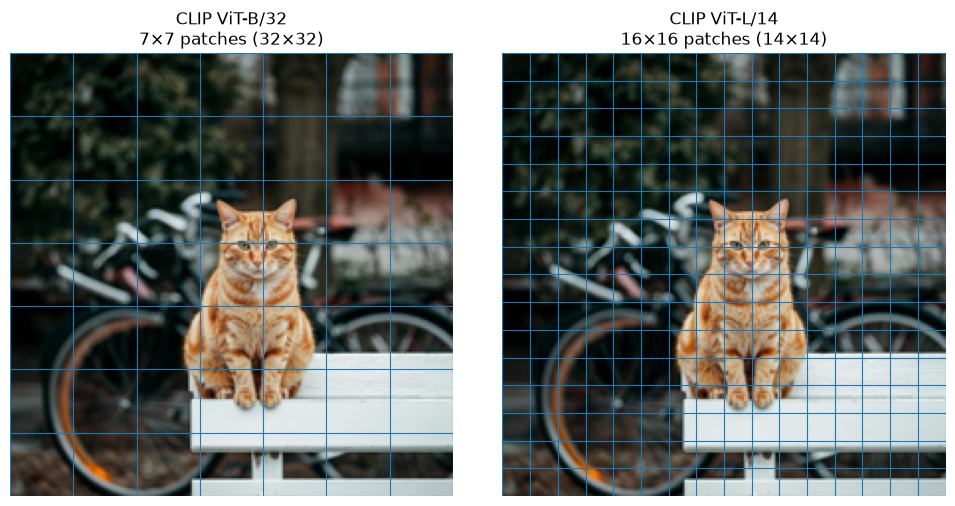

In [62]:
def draw_patch_grid(ax, img, patch_size, title):
    ax.imshow(img)
    image_size = img.size[0]

    for x in range(0, image_size + 1, patch_size):
        ax.axvline(x - 0.5, linewidth=0.8)

    for y in range(0, image_size + 1, patch_size):
        ax.axhline(y - 0.5, linewidth=0.8)

    n_patches = image_size // patch_size
    ax.set_title(f"{title}\n{n_patches}×{n_patches} patches ({patch_size}×{patch_size})")
    ax.axis("off")

row = train.iloc[7]

image_size = 224
img = (decode_image(row["image_1"]).resize((image_size, image_size)))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

draw_patch_grid(
    axes[0],
    img,
    patch_size=32,
    title="CLIP ViT-B/32"
)

draw_patch_grid(
    axes[1],
    img,
    patch_size=14,
    title="CLIP ViT-L/14"
)

plt.tight_layout()
plt.show()


### Загрузка весов эмбеддингов и тестовое обучение

In [ ]:
# вспомогательные функции для эмбеддингов

def extract_clip_embeddings(image_bytes_list, clip_base_encoder, clip_base_processor, batch_size=32):
    embeddings = []

    for start in tqdm(range(0, len(image_bytes_list), batch_size)):
        batch_bytes = image_bytes_list[start:start + batch_size]
        images = [decode_image(image_bytes) for image_bytes in batch_bytes]
        inputs = clip_base_processor(images=images, return_tensors='pt').to(DEVICE)

        with torch.no_grad():
            batch_embeddings = clip_base_encoder.get_image_features(**inputs)
            batch_embeddings = batch_embeddings / batch_embeddings.norm(dim=1, keepdim=True)

        embeddings.append(batch_embeddings.cpu().numpy())

    return np.vstack(embeddings)


# собираем признаки для пары эмбеддингов

def pair_embedding_features(emb_1, emb_2):
    emb_dim = emb_1.shape[1]

    X = np.hstack([
        emb_1,
        emb_2,
        emb_1 - emb_2,
        np.abs(emb_1 - emb_2),
        emb_1 * emb_2,
    ])

    # сохраняем имена признаков для feature importance
    columns = (
        [f'image_1_emb_{i}' for i in range(emb_dim)] +
        [f'image_2_emb_{i}' for i in range(emb_dim)] +
        [f'diff_emb_{i}' for i in range(emb_dim)] +
        [f'abs_diff_emb_{i}' for i in range(emb_dim)] +
        [f'mul_emb_{i}' for i in range(emb_dim)]
    )

    return pd.DataFrame(X, columns=columns)


In [128]:
CLIP_BASE_MODEL_NAME = 'openai/clip-vit-base-patch32'
CLIP_BASE_NAME = 'clip-vit-base-patch32'

clip_base_encoder = None
clip_base_processor = None


# загружаем модель CLIP Base и processor только один раз
def get_clip_base_encoder():
    global clip_base_encoder, clip_base_processor

    if clip_base_encoder is None:
        print(f'loading model: {CLIP_BASE_MODEL_NAME}')

        clip_base_encoder = CLIPModel.from_pretrained(CLIP_BASE_MODEL_NAME).to(DEVICE)
        clip_base_processor = CLIPProcessor.from_pretrained(CLIP_BASE_MODEL_NAME)
        clip_base_encoder.eval()

        print(f'model loaded: {type(clip_base_encoder)}')
        print(f'device: {DEVICE}')
    else:
        print('model already loaded')

    return clip_base_encoder, clip_base_processor


# загружаем эмбеддинги из файла или считаем их, если файла еще нет
def get_clip_base_embeddings(name, images):
    path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_{name}.npy'

    if path.exists():
        print(f'loading embeddings: {path}')
        embeddings = np.load(path)

        print(f'embeddings shape: {embeddings.shape}')

        return embeddings

    print(f'embeddings not found: {path}')
    print('calculating embeddings')

    clip_base_encoder, clip_base_processor = get_clip_base_encoder()
    embeddings = extract_clip_embeddings(images, clip_base_encoder, clip_base_processor)

    print(f'embeddings shape: {embeddings.shape}')
    print(f'saving embeddings: {path}')

    np.save(path, embeddings)

    return embeddings


In [66]:
clip_base_train_emb_1 = get_clip_base_embeddings('train_emb_1', train['image_1'].tolist())
clip_base_train_emb_2 = get_clip_base_embeddings('train_emb_2', train['image_2'].tolist())
clip_base_test_emb_1 = get_clip_base_embeddings('test_emb_1', test['image_1'].tolist())
clip_base_test_emb_2 = get_clip_base_embeddings('test_emb_2', test['image_2'].tolist())


loading embeddings: artefacts/clip-vit-base-patch32_train_emb_1.npy
embeddings shape: (8710, 512)
loading embeddings: artefacts/clip-vit-base-patch32_train_emb_2.npy
embeddings shape: (8710, 512)
loading embeddings: artefacts/clip-vit-base-patch32_test_emb_1.npy
embeddings shape: (4290, 512)
loading embeddings: artefacts/clip-vit-base-patch32_test_emb_2.npy
embeddings shape: (4290, 512)


In [ ]:
# формируем матрицы для обучения
X_clip_base = pair_embedding_features(clip_base_train_emb_1, clip_base_train_emb_2)
X_clip_base_test = pair_embedding_features(clip_base_test_emb_1, clip_base_test_emb_2)

target = train['is_image1_better'].astype(int).values

print(f'X_clip_base shape: {X_clip_base.shape}, type: {type(X_clip_base)}')
print(f'X_clip_base_test shape: {X_clip_base_test.shape}, type: {type(X_clip_base_test)}')
print(f'\ntarget shape: {target.shape}, type: {type(target)}')


X_clip shape: (8710, 2560), type: <class 'pandas.DataFrame'>
X_clip_test shape: (4290, 2560), type: <class 'pandas.DataFrame'>

target shape: (8710,), type: <class 'numpy.ndarray'>


In [ ]:
# Тестовое обучение по одному сплиту

# подберем параметры по небольшой сетке
param_grid = [
    {'iterations': 500, 'depth': 4, 'l2_leaf_reg': 3},
    {'iterations': 500, 'depth': 5, 'l2_leaf_reg': 3},
    {'iterations': 500, 'depth': 6, 'l2_leaf_reg': 3},
    {'iterations': 700, 'depth': 4, 'l2_leaf_reg': 5},
    {'iterations': 700, 'depth': 5, 'l2_leaf_reg': 5},
    {'iterations': 700, 'depth': 6, 'l2_leaf_reg': 5},
    {'iterations': 1000, 'depth': 4, 'l2_leaf_reg': 10},
    {'iterations': 1000, 'depth': 5, 'l2_leaf_reg': 10},
]

X_clip_base_train, X_clip_base_valid, target_train, target_valid = train_test_split(
    X_clip_base,
    target,
    test_size=0.2,
    random_state=SEED,
    stratify=target
)

results = []
best_auc = -1
clip_base_model = None

for params in param_grid:
    model = CatBoostClassifier(
        **params,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=SEED,
        verbose=False
    )

    model.fit(
        X_clip_base_train,
        target_train,
        eval_set=(X_clip_base_valid, target_valid),
        use_best_model=True
    )

    valid_pred = model.predict_proba(X_clip_base_valid)[:, 1]
    auc = roc_auc_score(target_valid, valid_pred)

    results.append({
        **params,
        'best_iteration': model.get_best_iteration(),
        'roc_auc': auc
    })

    # сохраняем лучшую модель для get_feature_importance
    if auc > best_auc:
        best_auc = auc
        clip_base_model = model    

    print(params, auc)

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
results_df


{'iterations': 500, 'depth': 4, 'l2_leaf_reg': 3} 0.6471254902873638
{'iterations': 500, 'depth': 5, 'l2_leaf_reg': 3} 0.6579496386131124
{'iterations': 500, 'depth': 6, 'l2_leaf_reg': 3} 0.6442492347443523
{'iterations': 700, 'depth': 4, 'l2_leaf_reg': 5} 0.6483708492882833
{'iterations': 700, 'depth': 5, 'l2_leaf_reg': 5} 0.660556745306626
{'iterations': 700, 'depth': 6, 'l2_leaf_reg': 5} 0.6548042342206031
{'iterations': 1000, 'depth': 4, 'l2_leaf_reg': 10} 0.6610281195079086
{'iterations': 1000, 'depth': 5, 'l2_leaf_reg': 10} 0.6541000826359711


,iterations,depth,l2_leaf_reg,best_iteration,roc_auc
6,1000,4,10,920,0.661028
4,700,5,5,523,0.660557
1,500,5,3,494,0.657950
5,700,6,5,691,0.654804
7,1000,5,10,969,0.654100
3,700,4,5,690,0.648371
0,500,4,3,409,0.647125
2,500,6,3,362,0.644249


In [72]:
best_params = results_df.iloc[0][['iterations', 'depth', 'l2_leaf_reg']].to_dict()
best_params['iterations'] = int(best_params['iterations'])
best_params['depth'] = int(best_params['depth'])

print(f"Best parameters: {best_params}")


Best parameters: {'iterations': 1000, 'depth': 4, 'l2_leaf_reg': 10.0}


Посмотрим feature importance тестовой модели, обученной на одном split.\
На CV значения могут немного отличаться.

In [73]:
clip_base_importance = pd.DataFrame({
    'feature': X_clip_base.columns,
    'importance': clip_base_model.get_feature_importance()
}).sort_values('importance', ascending=False)

# важность по группам фич
clip_base_importance['feature_group'] = clip_base_importance['feature'].str.extract(
    r'^(image_1_emb|image_2_emb|diff_emb|abs_diff_emb|mul_emb)'
)

clip_base_group_importance = (
    clip_base_importance
    .groupby('feature_group', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
)

clip_base_group_importance.style.background_gradient('Blues', subset='importance')


,feature_group,importance
1,diff_emb,23.697274
0,abs_diff_emb,20.365642
3,image_2_emb,19.957528
2,image_1_emb,19.069790
4,mul_emb,16.909766


Модель больше всего использует признаки различия между картинками:
- diff_emb – в какую сторону отличается первая картинка от второй;
- abs_diff_emb – насколько сильно картинки отличаются по CLIP-координатам, без учета направления;
- image_1_emb и image_2_emb – сами эмбеддинги картинок по отдельности;
- mul_emb – похожесть/взаимодействие координат.

Парные признаки немного полезнее, чем просто эмбеддинги каждой картинки отдельно, но в целом распределение довольно равномерное.

### CatBoost


In [ ]:
# обучение на кросс-валидации

N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

clip_base_oof_pred = np.zeros(len(X_clip_base))
clip_base_test_pred = np.zeros(len(X_clip_base_test))
clip_base_fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_clip_base, target)):
    print(f"Fold {fold}")

    X_train = X_clip_base.iloc[train_idx]
    X_valid = X_clip_base.iloc[valid_idx]
    y_train = target[train_idx]
    y_valid = target[valid_idx]

    model = CatBoostClassifier(
        **best_params,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=SEED,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    valid_pred = model.predict_proba(X_valid)[:, 1]
    test_pred = model.predict_proba(X_clip_base_test)[:, 1]

    clip_base_oof_pred[valid_idx] = valid_pred
    clip_base_test_pred += test_pred / N_SPLITS

    fold_auc = roc_auc_score(y_valid, valid_pred)
    clip_base_fold_scores.append(fold_auc)

    print("bestIteration =", model.get_best_iteration())
    print(f"Fold {fold} ROC AUC:", fold_auc)
    print()

clip_base_cv_auc = roc_auc_score(target, clip_base_oof_pred)

print("Fold scores:", clip_base_fold_scores)
print("CV ROC AUC:", clip_base_cv_auc)


Fold 0
bestIteration = 518
Fold 0 ROC AUC: 0.6482638813173714

Fold 1
bestIteration = 395
Fold 1 ROC AUC: 0.654366645587562

Fold 2
bestIteration = 554
Fold 2 ROC AUC: 0.6432090108125095

Fold 3
bestIteration = 659
Fold 3 ROC AUC: 0.6448079004643908

Fold 4
bestIteration = 905
Fold 4 ROC AUC: 0.6421324154145184

Fold scores: [0.6482638813173714, 0.654366645587562, 0.6432090108125095, 0.6448079004643908, 0.6421324154145184]
CV ROC AUC: 0.6452269037838783


In [75]:
# сохраняем oof и test предсказания catboost
oof_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_oof_pred.npy'
test_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_test_pred.npy'

np.save(oof_path, clip_base_oof_pred)
np.save(test_path, clip_base_test_pred)

print(f'saved oof predictions:  {oof_path}')
print(f'saved test predictions: {test_path}')
print(f'oof shape:  {clip_base_oof_pred.shape}')
print(f'test shape: {clip_base_test_pred.shape}')


saved oof predictions:  artefacts/clip-vit-base-patch32_catboost_oof_pred.npy
saved test predictions: artefacts/clip-vit-base-patch32_catboost_test_pred.npy
oof shape:  (8710,)
test shape: (4290,)


### Siamese comparator

Здесь те же CLIP-эмбеддинги используются не в CatBoost, а в небольшой PyTorch-модели для сравнения пары изображений. Siamese-модель сначала одинаковой веткой преобразует эмбеддинги `image_1` и `image_2`, а потом MLP-компаратор получает признаки пары.


In [ ]:
# dataset для пары эмбеддингов

class SiameseDataset(Dataset):
    def __init__(self, emb_1, emb_2, y, augment_swap=False):
        # переводим эмбеддинги и метки в тензоры
        self.emb_1 = torch.tensor(emb_1, dtype=torch.float32)
        self.emb_2 = torch.tensor(emb_2, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

        self.augment_swap = augment_swap
        self.n = len(y)

    def __len__(self):
        return self.n * 2 if self.augment_swap else self.n

    def __getitem__(self, idx):
        if self.augment_swap and idx >= self.n:
            idx = idx - self.n
            return self.emb_2[idx], self.emb_1[idx], 1 - self.y[idx]

        return self.emb_1[idx], self.emb_2[idx], self.y[idx]


# siamese comparator для пары эмбеддингов
# tower — одна и та же нейросеть для обеих картинок:
# две картинки проходят через общую ветку с общими весами

class SiameseComparator(nn.Module):
    def __init__(self, emb_dim, tower_dims=(256,), head_dims=(256, 64), dropout=0.25):
        super().__init__()

        tower_layers = []
        prev_dim = emb_dim

        for hidden_dim in tower_dims:
            tower_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim

        self.tower = nn.Sequential(*tower_layers)
        tower_out_dim = prev_dim

        head_layers = []
        prev_dim = tower_out_dim * 4

        for hidden_dim in head_dims:
            head_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim

        head_layers.append(nn.Linear(prev_dim, 1))
        self.head = nn.Sequential(*head_layers)

    def forward(self, emb_1, emb_2):
        z1 = self.tower(emb_1)
        z2 = self.tower(emb_2)
        pair = torch.cat([
            z1,                     # представление image_1
            z2,                     # представление image_2
            z1 - z2,                # разность представлений
            torch.abs(z1 - z2)      # абсолютная разность представлений
            ], dim=1)

        return self.head(pair).squeeze(1)


In [ ]:
# инференс siamese-модели батчами
def predict_siamese_model(model, emb_1, emb_2, batch_size=512):
    model.eval()        # режим инференса
    preds = []

    # создаем dataset без target: y здесь нужен только формально для SiameseDataset
    loader = DataLoader(
        SiameseDataset(emb_1, emb_2, np.zeros(len(emb_1))),
        batch_size=batch_size,
        shuffle=False
    )

    # отключаем расчет градиентов, модель здесь не обучается
    with torch.no_grad():
        for batch_emb_1, batch_emb_2, _ in loader:
            # считаем logits для батча
            logits = model(batch_emb_1.to(DEVICE), batch_emb_2.to(DEVICE))

            # переводим logits в вероятности класса 1
            preds.append(torch.sigmoid(logits).cpu().numpy())

    # склеиваем предсказания всех батчей в один массив
    return np.concatenate(preds)


# обучение одной siamese-модели с early stopping по validation auc
def train_siamese_model(
    model,
    emb_1_train,
    emb_2_train,
    y_train,
    emb_1_valid,
    emb_2_valid,
    y_valid,

    augment_swap=False,
    lr=7e-4,
    weight_decay=1e-4,
    batch_size=256,
    epochs=25,
    patience=5
):
    model = model.to(DEVICE)

    # режем на батчи и перемешиваем
    train_loader = DataLoader(
        SiameseDataset(emb_1_train, emb_2_train, y_train, augment_swap=augment_swap),
        batch_size=batch_size,
        shuffle=True
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_auc = -np.inf
    best_epoch = 0
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()                   # режим обучения
        losses = []

        for batch_emb_1, batch_emb_2, batch_y in train_loader:
            batch_emb_1 = batch_emb_1.to(DEVICE)
            batch_emb_2 = batch_emb_2.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()                       # зануляем градиенты перед обратным проходом
            logits = model(batch_emb_1, batch_emb_2)    # считаем logits для батча
            loss = criterion(logits, batch_y)           # считаем loss для батча
            loss.backward()                             # считаем градиенты
            optimizer.step()                            # обновляем веса модели

            losses.append(loss.item())

        # проверка на валидации
        valid_pred = predict_siamese_model(model, emb_1_valid, emb_2_valid)
        valid_auc = roc_auc_score(y_valid, valid_pred)

        print(f'epoch: {epoch:02d}, loss: {np.mean(losses):.4f}, valid_auc: {valid_auc:.6f}')

        # сохраняем лучшую модель по валидации
        if valid_auc > best_auc:
            best_auc = valid_auc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        # early stopping
        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)       # загружаем веса лучшей модели по валидации

    return model, best_auc, best_epoch


In [ ]:
# обучение siamese comparator на кросс-валидации

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

siamese_oof_pred = np.zeros(len(train))
siamese_test_pred = np.zeros(len(test))
siamese_fold_scores = []
siamese_best_epochs = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(clip_base_train_emb_1, target)):
    print(f'fold {fold}')
    set_seed(SEED + fold)      # немного меняем сид для каждого фолда

    model = SiameseComparator(
        emb_dim=clip_base_train_emb_1.shape[1],
        tower_dims=(256,),
        head_dims=(256, 64),
        dropout=0.25
    )

    model, fold_auc, best_epoch = train_siamese_model(
        model,
        clip_base_train_emb_1[train_idx],
        clip_base_train_emb_2[train_idx],
        target[train_idx],
        clip_base_train_emb_1[valid_idx],
        clip_base_train_emb_2[valid_idx],
        target[valid_idx],
        
        augment_swap=False,
        lr=7e-4,
        weight_decay=1e-4,
        batch_size=256,
        epochs=25,
        patience=5
    )

    valid_pred = predict_siamese_model(
        model,
        clip_base_train_emb_1[valid_idx],
        clip_base_train_emb_2[valid_idx]
    )
    test_pred = predict_siamese_model(model, clip_base_test_emb_1, clip_base_test_emb_2)

    siamese_oof_pred[valid_idx] = valid_pred
    siamese_test_pred += test_pred / N_SPLITS

    siamese_fold_scores.append(fold_auc)
    siamese_best_epochs.append(best_epoch)

    print(f'best epoch: {best_epoch}')
    print(f'fold ROC AUC: {fold_auc:.6f}')
    print()

siamese_cv_auc = roc_auc_score(target, siamese_oof_pred)

print('fold scores:', siamese_fold_scores)
print('best epochs:', siamese_best_epochs)
print(f'CV ROC AUC: {siamese_cv_auc:.6f}')


fold 0
epoch: 01, loss: 0.6560, valid_auc: 0.577809
epoch: 02, loss: 0.6409, valid_auc: 0.598857
epoch: 03, loss: 0.6268, valid_auc: 0.621062
epoch: 04, loss: 0.6121, valid_auc: 0.637279
epoch: 05, loss: 0.5905, valid_auc: 0.646845
epoch: 06, loss: 0.5732, valid_auc: 0.649549
epoch: 07, loss: 0.5532, valid_auc: 0.652391
epoch: 08, loss: 0.5386, valid_auc: 0.652544
epoch: 09, loss: 0.5184, valid_auc: 0.652634
epoch: 10, loss: 0.5022, valid_auc: 0.649699
epoch: 11, loss: 0.4864, valid_auc: 0.650410
epoch: 12, loss: 0.4506, valid_auc: 0.640707
epoch: 13, loss: 0.4482, valid_auc: 0.635637
epoch: 14, loss: 0.4188, valid_auc: 0.638993
best epoch: 9
fold ROC AUC: 0.652634

fold 1
epoch: 01, loss: 0.6584, valid_auc: 0.596694
epoch: 02, loss: 0.6393, valid_auc: 0.622392
epoch: 03, loss: 0.6237, valid_auc: 0.634708
epoch: 04, loss: 0.6067, valid_auc: 0.644948
epoch: 05, loss: 0.5861, valid_auc: 0.649488
epoch: 06, loss: 0.5737, valid_auc: 0.653521
epoch: 07, loss: 0.5566, valid_auc: 0.649444
epo

In [107]:
print(f'mean ROC AUC: {np.mean(siamese_fold_scores):.5f}')
print(f'std ROC AUC:  {np.std(siamese_fold_scores):.5f}')
print(f'min ROC AUC:  {np.min(siamese_fold_scores):.5f}')
print(f'max ROC AUC:  {np.max(siamese_fold_scores):.5f}')


mean ROC AUC: 0.65506
std ROC AUC:  0.00773
min ROC AUC:  0.64521
max ROC AUC:  0.66897


| augment_swap | mean ROC AUC | std ROC AUC | min ROC AUC | max ROC AUC |
|---|---:|---:|---:|---:|
| `True` | 0.64673 | 0.00760 | 0.63921 | 0.66136 |
| `False` | 0.65506 | 0.00773 | 0.64521 | 0.66897 |

При augment_swap=False качество лучше, средний ROC AUC выше. Разброс по фолдам почти не изменился, то есть модель не стала стабильнее, но стала системно сильнее.

In [129]:
# сохраняем oof и test предсказания siamese comparator
siamese_oof_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_siamese_oof_pred.npy'
siamese_test_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_siamese_test_pred.npy'

np.save(siamese_oof_path, siamese_oof_pred)
np.save(siamese_test_path, siamese_test_pred)

print(f'saved oof predictions:  {siamese_oof_path}')
print(f'saved test predictions: {siamese_test_path}')


saved oof predictions:  artefacts/clip-vit-base-patch32_siamese_oof_pred.npy
saved test predictions: artefacts/clip-vit-base-patch32_siamese_test_pred.npy


### CatBoost + Siamese blend

Проверяем, дополняет ли Siamese comparator CatBoost на тех же CLIP-эмбеддингах. Вес подбирается только по OOF-предсказаниям.


In [ ]:
# подбираем веса catboost/siamese blend по oof
catboost_oof_pred = np.load(ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_oof_pred.npy')
catboost_test_pred = np.load(ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_test_pred.npy')

siamese_oof_pred = np.load(ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_siamese_oof_pred.npy')
siamese_test_pred = np.load(ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_siamese_test_pred.npy')

blend_results = []

for catboost_weight in np.arange(0, 1.01, 0.05):
    siamese_weight = 1 - catboost_weight
    blend_oof_pred = catboost_weight * catboost_oof_pred + siamese_weight * siamese_oof_pred
    blend_auc = roc_auc_score(target, blend_oof_pred)

    blend_results.append({
        'catboost_weight': catboost_weight,
        'siamese_weight': siamese_weight,
        'roc_auc': blend_auc
    })

blend_results = pd.DataFrame(blend_results).sort_values('roc_auc', ascending=False)
blend_results.head(10).style.background_gradient('Blues', subset='roc_auc')


,catboost_weight,siamese_weight,roc_auc
13,0.650000,0.350000,0.658769
12,0.600000,0.400000,0.658739
11,0.550000,0.450000,0.658546
14,0.700000,0.300000,0.658523
10,0.500000,0.500000,0.658136
15,0.750000,0.250000,0.657946
9,0.450000,0.550000,0.657560
16,0.800000,0.200000,0.656894
8,0.400000,0.600000,0.656872
7,0.350000,0.650000,0.656166


In [ ]:
# сохраняем лучший catboost/siamese blend как отдельный атомарный кандидат
best_blend = blend_results.iloc[0]
catboost_weight = best_blend['catboost_weight']
siamese_weight = best_blend['siamese_weight']

blend_oof_pred = catboost_weight * catboost_oof_pred + siamese_weight * siamese_oof_pred
blend_test_pred = catboost_weight * catboost_test_pred + siamese_weight * siamese_test_pred

blend_oof_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_siamese_blend_oof_pred.npy'
blend_test_path = ARTEFACTS_DIR / f'{CLIP_BASE_NAME}_catboost_siamese_blend_test_pred.npy'

np.save(blend_oof_path, blend_oof_pred)
np.save(blend_test_path, blend_test_pred)

print(f'CLIP ViT-B/32 CatBoost ROC AUC: {roc_auc_score(target, catboost_oof_pred):.6f}; weight: {catboost_weight:.2f}; ')
print(f'CLIP ViT-B/32 Siamese  ROC AUC: {roc_auc_score(target, siamese_oof_pred):.6f}; weight: {siamese_weight:.2f}; ')
print(f'Blend OOF preds        ROC AUC: {roc_auc_score(target, blend_oof_pred):.6f}\n')

print(f'saved oof predictions:  {blend_oof_path}')
print(f'saved test predictions: {blend_test_path}')


CLIP ViT-B/32 CatBoost ROC AUC: 0.645227; weight: 0.65; 
CLIP ViT-B/32 Siamese  ROC AUC: 0.650378; weight: 0.35; 
Blend OOF preds        ROC AUC: 0.658769

saved oof predictions:  artefacts/clip-vit-base-patch32_catboost_siamese_blend_oof_pred.npy
saved test predictions: artefacts/clip-vit-base-patch32_catboost_siamese_blend_test_pred.npy


Standalone Siamese оказался сильнее standalone CatBoost; лучший blend все равно дает больший вес CatBoost. Вес в blend зависит не только от индивидуального ROC AUC, но и от того, какие ошибки модель делает. Итоговый blend по ROC AUC заметно выше обеих отдельных моделей,  CatBoost и Siamese действительно дополняют друг друга.

---

## CLIP ViT Large

**Encoder:** `openai/clip-vit-large-patch14`  
**Source:** Hugging Face / transformers  
**Backbone:** ViT-L/14  
**Input size:** 224×224  
**Patch size:** 14×14  
**Models:** CatBoost, Siamese comparator

Вторая CLIP-ветка использует более крупный encoder и более мелкие патчи. 

<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### Embeddings


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### CatBoost


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### Siamese comparator


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### CatBoost + Siamese blend


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

---

## SigLIP 256

**Encoder:** `google/siglip-large-patch16-256`  
**Source:** Hugging Face / transformers  
**Backbone:** ViT-L/16  
**Input size:** 256×256  
**Patch size:** 16×16  
**Models:** CatBoost seed ensemble, Siamese comparator


Несмотря на то что SigLIP тоже ViT, изменилась не только модель, но и сама цель предобучения (sigmoid вместо contrastive loss). Это дало еще один независимый источник сигнала, сравнимый по величине с добавлением CLIP Large.

| Модель | Размер входа | Patch | Сетка | Число патчей |
|---|---:|---:|---:|---:|
| CLIP ViT-L/14 | 224 | 14 | 16×16 | 256 |
| SigLIP-L/16-256 | 256 | 16 | 16×16 | 256 |
| SigLIP-L/16-384 | 384 | 16 | 24×24 | 576 |

CLIP ViT-L/14 и SigLIP-L/16-256 имеют одинаковое число визуальных токенов (256), получают их по-разному: CLIP L/14 использует более мелкие патчи (14×14), но меньшее входное изображение (224×224), SigLIP использует более крупные патчи (16×16), но большее входное изображение (256×256); поэтому пространственное разрешение получается практически одинаковым.

SigLIP-L/16-384 использует тот же размер патча (16×16), но большее входное изображение (384×384), поэтому получает более плотную сетку 24×24 и 576 визуальных токенов.


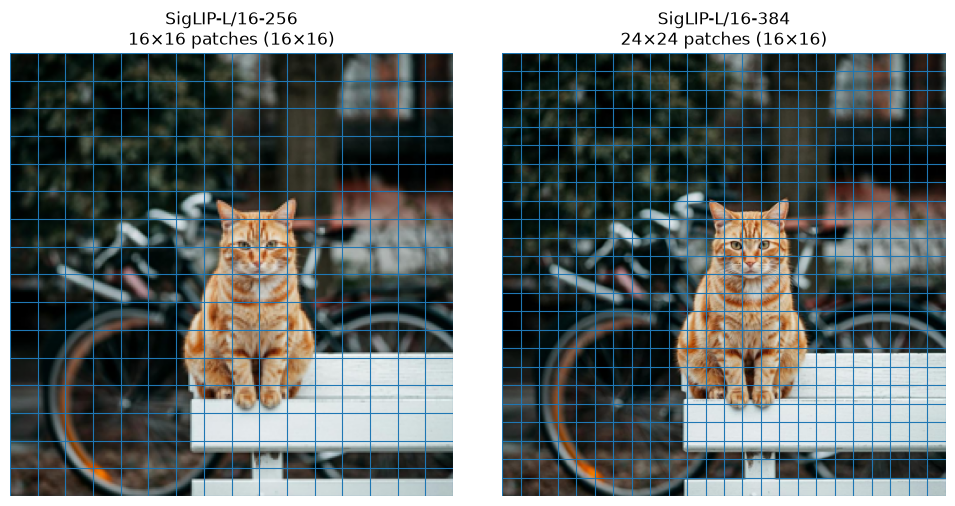

In [113]:
# график
row = train.iloc[7]

img_256 = decode_image(row['image_1']).resize((256, 256))
img_384 = decode_image(row['image_1']).resize((384, 384))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

draw_patch_grid(
    axes[0],
    img_256,
    patch_size=16,
    title='SigLIP-L/16-256'
)

draw_patch_grid(
    axes[1],
    img_384,
    patch_size=16,
    title='SigLIP-L/16-384'
)

plt.tight_layout()
plt.show()


### Embeddings


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### CatBoost seed ensemble


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### Siamese comparator


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### CatBoost + Siamese blend


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

## SigLIP 384

**Encoder:** `google/siglip-large-patch16-384`  
**Source:** Hugging Face / transformers  
**Backbone:** ViT-L/16  
**Input size:** 384×384  
**Patch size:** 16×16  
**Models:** CatBoost

Версия SigLIP с большим входным разрешением.


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

---

## OpenCLIP ConvNeXt

**Encoder:** `convnext_base_w`  
**Pretrained weights:** laion2b_s13b_b82k_augreg  
**Source:** open_clip  
**Backbone:** ConvNeXt Base W  
**Models:** CatBoost


OpenCLIP ConvNeXt основана не на Vision Transformer, а на сверточной архитектуре. Это позволяет извлекать признаки другим способом и делает ее дополнением к ViT-моделям.

<style>
  .convnext-table {
    border-collapse: collapse;
    width: 100%;
    font-size: 14px;
    text-align: center;
  }

  .convnext-table th,
  .convnext-table td {
    padding: 8px;
    border: 1px solid #d1d5db;
    text-align: center;
    vertical-align: middle;
  }
</style>

<table class="convnext-table">
  <thead>
    <tr>
      <th>Input</th>
      <th>Preprocessing</th>
      <th>Stem</th>
      <th>Stage 1</th>
      <th>Stage 2</th>
      <th>Stage 3</th>
      <th>Stage 4</th>
      <th>Pooling</th>
      <th>Embedding</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>image</td>
      <td>resize + center crop<br>normalize pixels<br>256×256</td>
      <td>64×64×128</td>
      <td>64×64×128</td>
      <td>32×32×256</td>
      <td>16×16×512</td>
      <td>8×8×1024</td>
      <td>global <br>average <br>pooling</td>
      <td>1024-d</td>
    </tr>
  </tbody>
</table>

* **Preprocessing** — приводит все изображения к одному размеру и масштабу значений пикселей, чтобы они соответствовали условиям, в которых модель была предобучена.
* **Stem** — первый сверточный слой. Он уменьшает пространственное разрешение изображения в 4 раза и преобразует RGB-пиксели в первые карты признаков (feature maps).

* **Stage 1–4** — последовательно извлекают все более сложные признаки. Пространственное разрешение уменьшается, а число каналов растет.
* **Global average pooling** — усредняет каждую карту признаков, превращая пространственное представление 8×8×1024 в один вектор длиной 1024.
* **Embedding** — итоговое представление изображения, которое затем используется для сравнения изображений или как вход CatBoost.

In [118]:
# настройки ConvNeXt
CONVNEXT_MODEL_NAME = 'convnext_base_w'
CONVNEXT_PRETRAINED = 'laion2b_s13b_b82k_augreg'

convnext_encoder = None
convnext_preprocess = None


# загружаем ConvNeXt encoder и preprocessing только один раз
def get_convnext_encoder():
    global convnext_encoder, convnext_preprocess

    if convnext_encoder is None:
        print('loading encoder:', CONVNEXT_MODEL_NAME)
        print('pretrained weights:', CONVNEXT_PRETRAINED)

        convnext_encoder, _, convnext_preprocess = open_clip.create_model_and_transforms(
            CONVNEXT_MODEL_NAME,
            pretrained=CONVNEXT_PRETRAINED,
            device=DEVICE
        )

        convnext_encoder.eval()

        print('encoder loaded')
        print('device:', DEVICE)

    return convnext_encoder, convnext_preprocess


In [ ]:
# извлекаем промежуточные feature maps ConvNeXt

convnext_encoder, convnext_preprocess = get_convnext_encoder()
convnext_encoder.eval()

row = train.iloc[7]
image = decode_image(row['image_1'])
x = convnext_preprocess(image).unsqueeze(0).to(DEVICE)

feature_maps = {}

def save_feature_map(name):
    def hook(module, inputs, output):
        feature_maps[name] = output.detach().cpu()
    return hook

hooks = []
for i, stage in enumerate(convnext_encoder.visual.trunk.stages):
    hooks.append(
        stage.register_forward_hook(save_feature_map(f'stage_{i + 1}'))
    )

with torch.no_grad():
    _ = convnext_encoder.encode_image(x)

for hook in hooks:
    hook.remove()

for name, feature_map in feature_maps.items():
    print(name, feature_map.shape)


loading encoder: convnext_base_w laion2b_s13b_b82k_augreg


encoder loaded
device: mps
stage_1 torch.Size([1, 128, 64, 64])
stage_2 torch.Size([1, 256, 32, 32])
stage_3 torch.Size([1, 512, 16, 16])
stage_4 torch.Size([1, 1024, 8, 8])


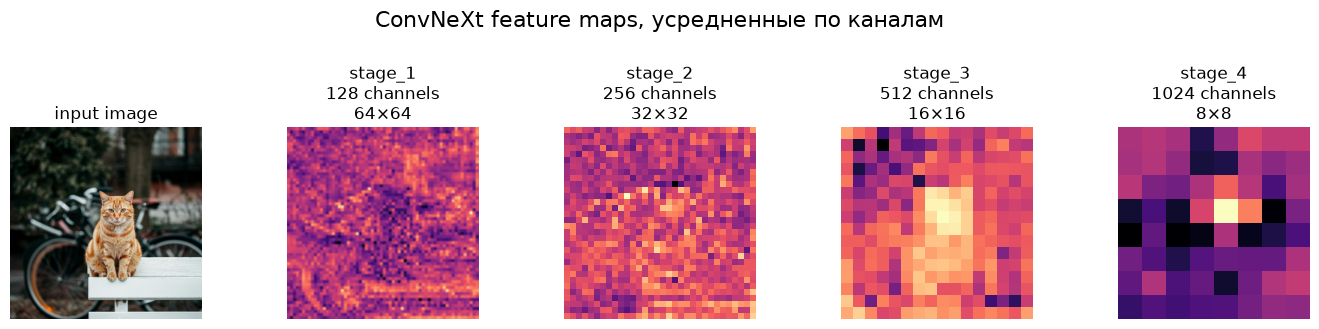

In [ ]:
# визуализируем feature maps

fig, axes = plt.subplots(1, len(feature_maps) + 1, figsize=(14, 3))

axes[0].imshow(image)
axes[0].set_title('input image')
axes[0].axis('off')

for ax, (name, feature_map) in zip(axes[1:], feature_maps.items()):
    channels = feature_map.shape[1]
    height = feature_map.shape[2]
    width = feature_map.shape[3]

    fmap = feature_map[0].mean(axis=0).numpy()

    ax.imshow(fmap, cmap='magma')
    ax.set_title(f'{name}\n{channels} channels\n{height}×{width}')
    ax.axis('off')

plt.suptitle('ConvNeXt feature maps, усредненные по каналам сверточных слоев', fontsize=16, y=1.08)
plt.tight_layout()
plt.show()


По мере прохождения через ConvNeXt пространственное разрешение уменьшается (64×64 → 8×8), число каналов увеличивается (128 → 1024). На ранних этапах сеть реагирует на локальные текстуры и границы, на поздних концентрируется на наиболее информативных областях изображения. Карты полученны усреднением активаций по всем каналам каждого stage.

- **Stage 1** (128×64×64): модель еще почти не выделяет объекты. Активность распределена почти по всему изображению, кошка еще не отделена от фона.
- **Stage 2** (256×32×32): Начинают проявляться более крупные структуры. Кошка становится заметнее, фон постепенно теряет детализацию.
- **Stage 3** (512×16×16): основная активность уже сосредоточена на главном объекте. 
- **Stage 4** (1024×8×8): Карта очень грубая пространственно (всего 8×8 клетки), зато содержит 1024 канала. Она уже не хранит детали изображения, а показывает, где расположены наиболее важные области для формирования итогового embedding.

first conv: stem.0 torch.Size([128, 3, 4, 4])


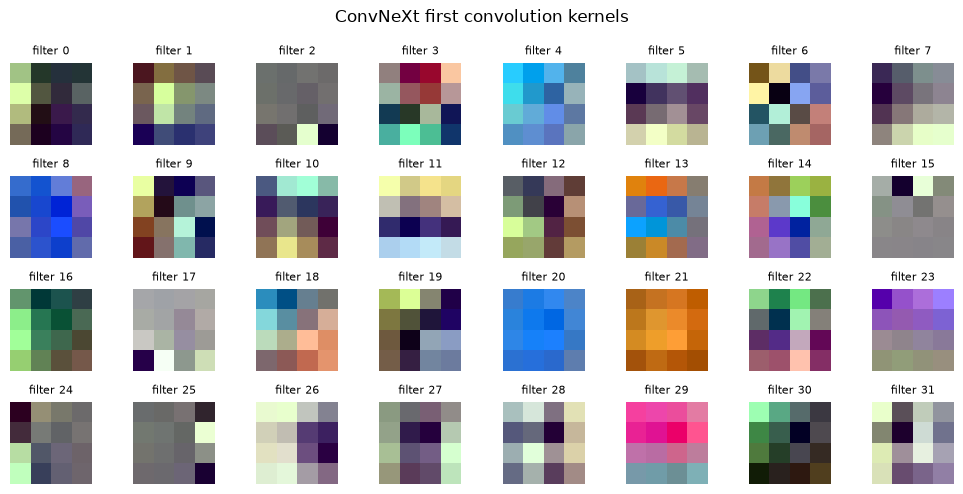

In [ ]:
# визуализируем первые convolution kernels stem

first_conv = None

convnext_encoder, _ = get_convnext_encoder()

for name, module in convnext_encoder.visual.trunk.named_modules():
    if isinstance(module, nn.Conv2d):
        first_conv = module
        print('first conv:', name, module.weight.shape)
        break

weights = first_conv.weight.detach().cpu()

n_filters = min(32, weights.shape[0])

fig, axes = plt.subplots(4, 8, figsize=(10, 5))

for ax, idx in zip(axes.ravel(), range(n_filters)):
    kernel = weights[idx]

    # если kernel имеет 3 входных канала:
    if kernel.shape[0] == 3:
        kernel_img = kernel.permute(1, 2, 0).numpy()
        kernel_img = (kernel_img - kernel_img.min()) / (kernel_img.max() - kernel_img.min() + 1e-9)

        ax.imshow(kernel_img)
    else:
        kernel_img = kernel.mean(axis=0).numpy()
        ax.imshow(kernel_img, cmap='gray')

    ax.set_title(f'filter {idx}', fontsize=8)
    ax.axis('off')

plt.suptitle('ConvNeXt first convolution kernels')
plt.tight_layout()
plt.show()


**Веса первых 32 из 128 фильтров первого сверточного слоя (stem)**.  
torch.Size([128, 3, 4, 4]):  128 фильтров, каждый принимает 3 RGB-канала, размер ядра 4×4.     
Они преобразуют исходное изображение в 128 карт признаков размером 64×64, которые становятся входом для последующих блоков ConvNeXt. Эти фильтры фиксированы и одинаковы для любого изображения. Каждый фильтр содержит отдельные веса для каналов RGB, поэтому при визуализации они выглядят разноцветными и могут по-разному реагировать на различные сочетания цветов, границ и текстур.

<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

---

## EVA-CLIP Base

**Encoder:** `EVA02-B-16`  
**Pretrained weights:** merged2b_s8b_b131k  
**Source:** open_clip  
**Backbone:** EVA-CLIP Base, ViT-B/16  
**Patch size:** 16×16  
**Models:** CatBoost seed ensemble

EVA-B оказался одной из самых сильных отдельных веток, поэтому для него дополнительно используется CatBoost seed ensemble.


| Модель        | Размер входа | Patch | Сетка | Число токенов |
| ------------- | -----------: | ----: | ----: | ------------: |
| CLIP ViT-L/14 |          224 |    14 | 16×16 |           256 |
| EVA02-L-14    |          224 |    14 | 16×16 |           256 |
| EVA02-B-16    |          224 |    16 | 14×14 |           196 |

EVA-CLIP сохраняет архитектуру Vision Transformer, но использует другое предобучение и значительно больший объем данных.

<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

## EVA-CLIP Large

**Encoder:** `EVA02-L-14`  
**Pretrained weights:** merged2b_s4b_b131k  
**Source:** open_clip  
**Backbone:** EVA-CLIP Large, ViT-L/14  
**Patch size:** 14×14  
**Models:** CatBoost


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

---

## Weight stabilization

После получения atomic OOF/test predictions веса ансамбля подбираются на OOF-предсказаниях и стабилизируются усреднением лучших весовых векторов.


### Atomic OOF/test prediction matrix


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### Base weights


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### Dirichlet weight search

Вместо поиска полностью новых весов выполняется локальный поиск вокруг уже найденного устойчивого решения.

<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

### Top-100 weight averaging


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>

---

## Final prediction

Финальное предсказание получается как weighted sum atomic test predictions с усредненными стабильными весами.


<div style="
    border: 1px solid #d1d5db;
    background: #f9fafb;
    color: #4b5563;
    padding: 10px 12px;
    border-radius: 6px;
    box-sizing: border-box;
    max-width: 100%;
    font-size: 14px;
    line-height: 1.5;
    height: 100px;
    display: flex;
    align-items: center;
    justify-content: center;
    text-align: center;
">
    Раздел находится в процессе переноса из рабочего ноутбука и будет дополнен в ближайшее время.
</div>